# Explore here

In [103]:
pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [105]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"

df = pd.read_csv(url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [106]:
df.shape

(1338, 7)

In [107]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

EXPLORACIÓN Y LIMPIEZA DE DATOS

In [108]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [109]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [110]:
print("Filas antes de eliminar duplicados:", df.shape[0])
df = df.drop_duplicates()
print("Filas después de eliminar duplicados:", df.shape[0])

Filas antes de eliminar duplicados: 1338
Filas después de eliminar duplicados: 1337


In [111]:
df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


ANÁLISIS DE VARIABLES UNIVARIANTE

Distribución sex:
 sex
male      675
female    662
Name: count, dtype: int64


/tmp/ipykernel_1449/4050586126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', ax=axes[0], palette='pastel')


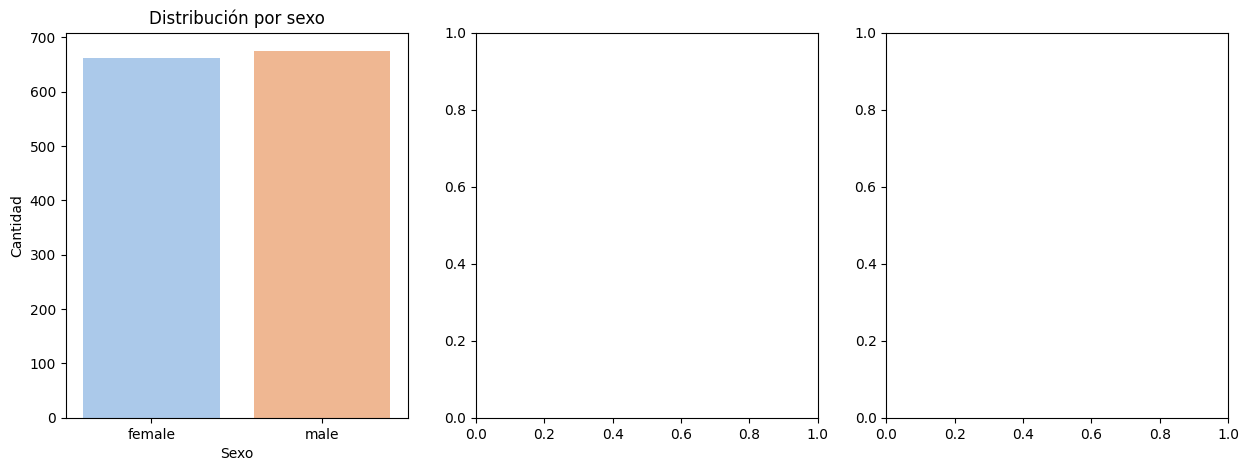

In [112]:
#VARIABLES CATEGÓRICAS
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(data=df, x='sex', ax=axes[0], palette='pastel')
axes[0].set_title('Distribución por sexo')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Cantidad')
print("Distribución sex:\n", df['sex'].value_counts())

In [113]:
sns.countplot(data=df, x='smoker', ax=axes[1], palette='pastel')
axes[1].set_title('Distribución fumadores')
axes[1].set_xlabel('¿Fumador?')
axes[1].set_ylabel('Cantidad')

print("\nDistribución smoker:\n", df['smoker'].value_counts())


Distribución smoker:
 smoker
no     1063
yes     274
Name: count, dtype: int64


/tmp/ipykernel_1449/960381394.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='smoker', ax=axes[1], palette='pastel')


In [114]:
sns.countplot(data=df, x='region', ax=axes[2], palette='pastel')
axes[2].set_title('Distribución por región')
axes[2].set_xlabel('Región')
axes[2].set_ylabel('Cantidad')
axes[2].tick_params(axis='x', rotation=15)
print("\nDistribución region:\n", df['region'].value_counts())
plt.tight_layout()
plt.show()


Distribución region:
 region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


/tmp/ipykernel_1449/1288375959.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='region', ax=axes[2], palette='pastel')


<Figure size 640x480 with 0 Axes>

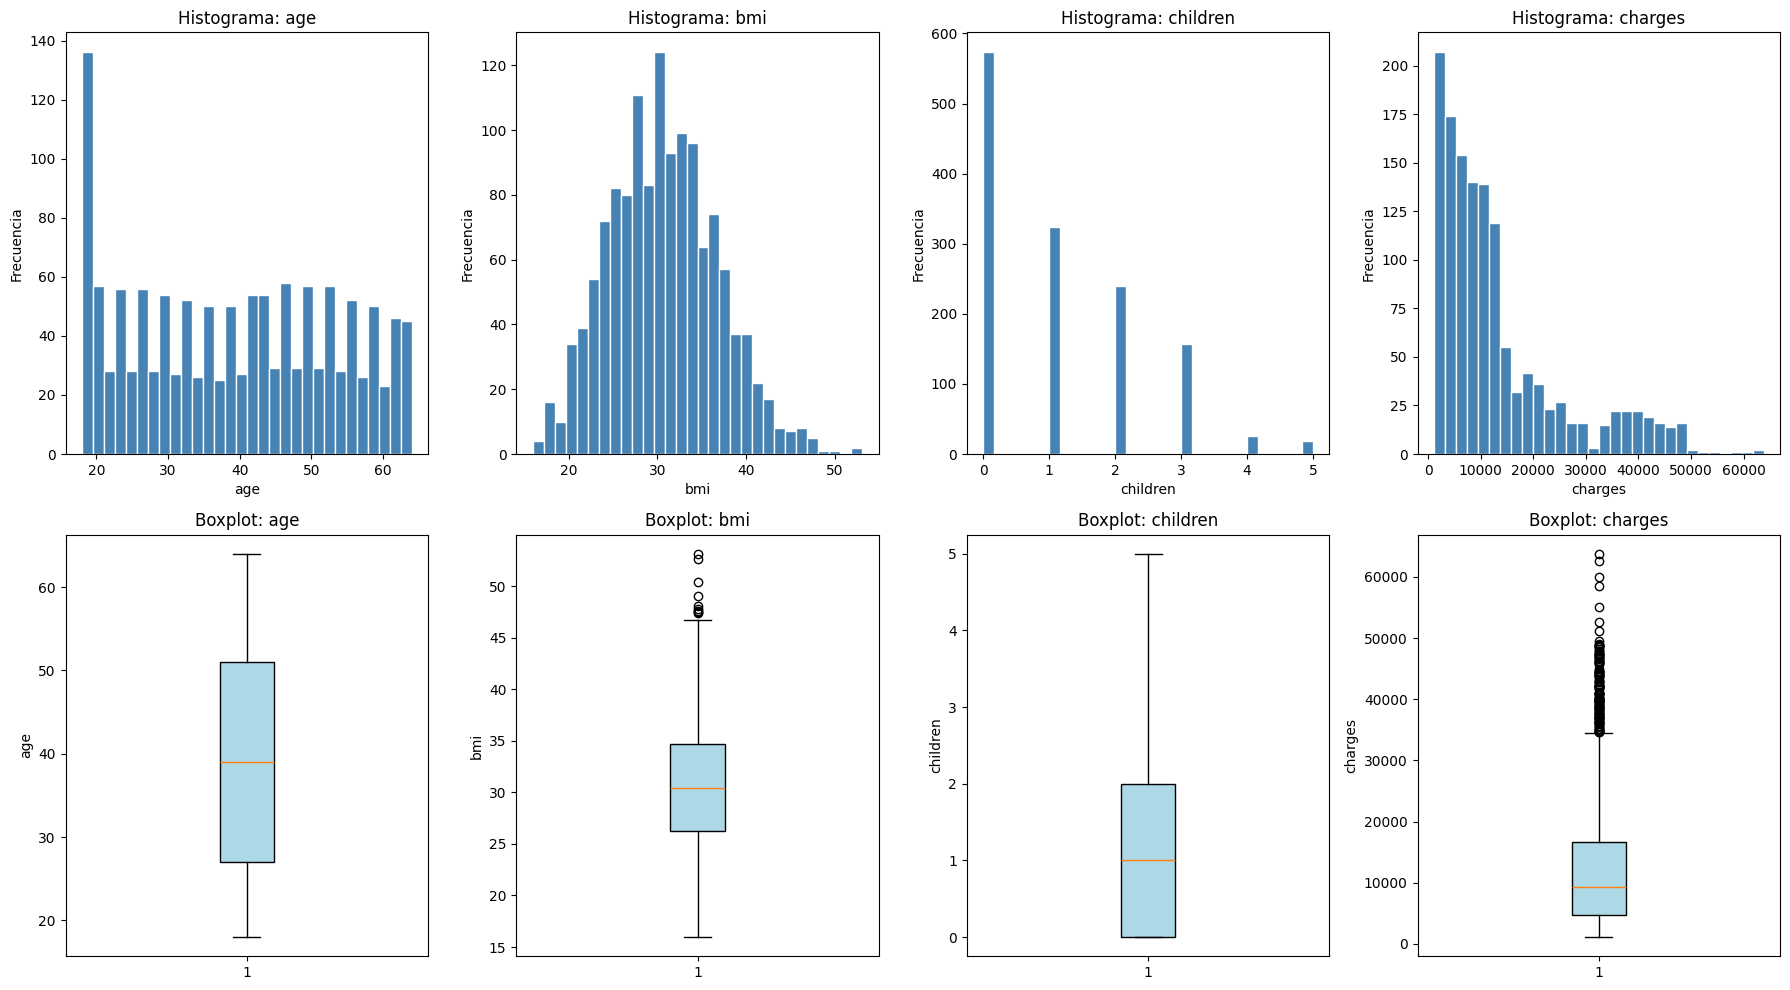

In [115]:
#VARIABLES NUMÉRICAS
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
num_cols = ['age', 'bmi', 'children', 'charges']
for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col], bins=30, color='steelblue', edgecolor='white')   
    axes[0, i].set_title(f'Histograma: {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frecuencia')

    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))

    axes[1, i].set_title(f'Boxplot: {col}')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [116]:
for col in num_cols:
    print(f"\n{'='*40}")
    print(f"Variable: {col}")
    print(f"  Media:    {df[col].mean():.2f}")
   
    print(f"  Mediana:  {df[col].median():.2f}")

    print(f"  Std:      {df[col].std():.2f}")

    print(f"  Mín:      {df[col].min():.2f}")
    print(f"  Máx:      {df[col].max():.2f}")

    skew = df[col].skew()
    print(f"  Skewness: {skew:.2f}")


Variable: age
  Media:    39.22
  Mediana:  39.00
  Std:      14.04
  Mín:      18.00
  Máx:      64.00
  Skewness: 0.05

Variable: bmi
  Media:    30.66
  Mediana:  30.40
  Std:      6.10
  Mín:      15.96
  Máx:      53.13
  Skewness: 0.28

Variable: children
  Media:    1.10
  Mediana:  1.00
  Std:      1.21
  Mín:      0.00
  Máx:      5.00
  Skewness: 0.94

Variable: charges
  Media:    13279.12
  Mediana:  9386.16
  Std:      12110.36
  Mín:      1121.87
  Máx:      63770.43
  Skewness: 1.52


ANÁLISIS DE VARIABLES MULTIVARIANTE

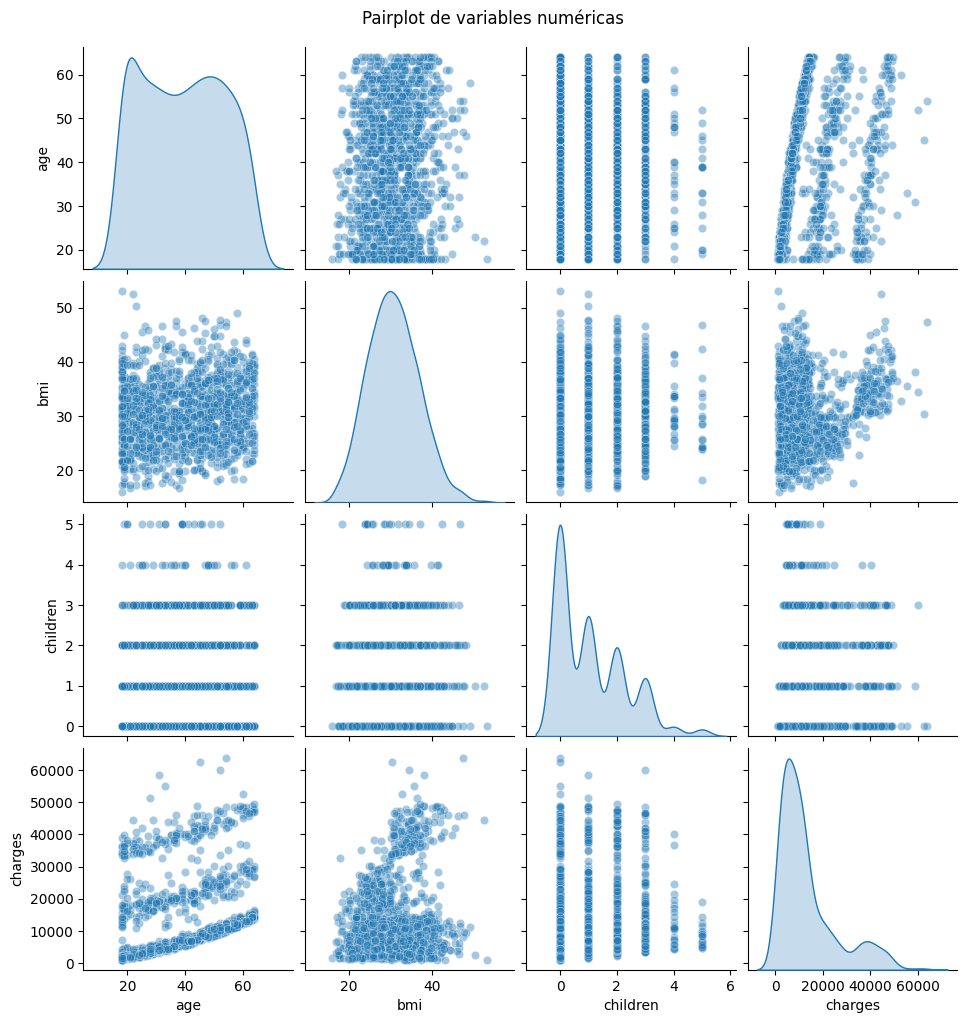

In [117]:
sns.pairplot(df[num_cols], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot de variables numéricas', y=1.02)
plt.show()

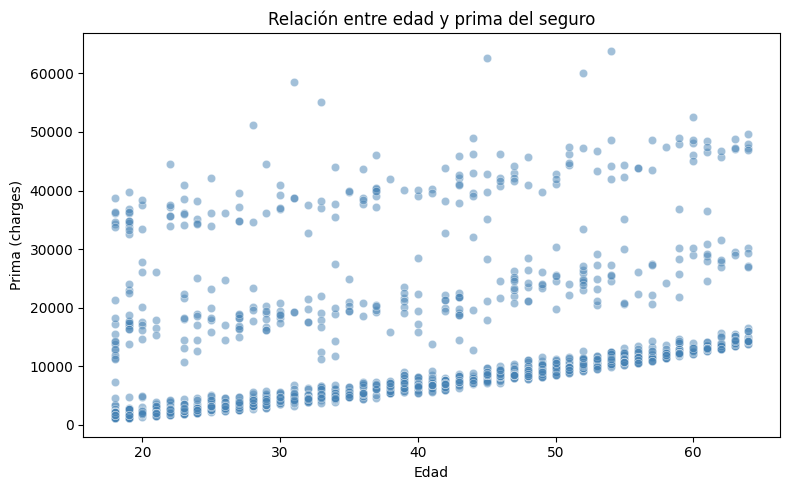

In [118]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', alpha=0.5, color='steelblue')

plt.title('Relación entre edad y prima del seguro')
plt.xlabel('Edad')
plt.ylabel('Prima (charges)')
plt.tight_layout()
plt.show()

ANÁLISIS CATEGÓRICO - CATEGÓRICO

Tabla cruzada sex vs smoker:
 smoker   no  yes
sex             
female  547  115
male    516  159


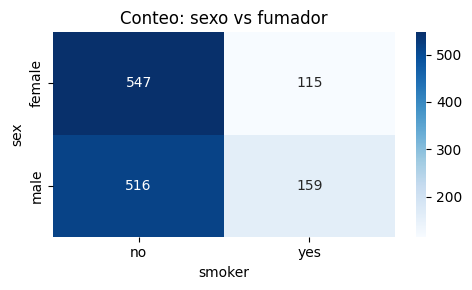

In [119]:
cross_sex_smoker = pd.crosstab(df['sex'], df['smoker'])
print("Tabla cruzada sex vs smoker:\n", cross_sex_smoker)

plt.figure(figsize=(5, 3))
sns.heatmap(cross_sex_smoker, annot=True, fmt='d', cmap='Blues')

plt.title('Conteo: sexo vs fumador')
plt.tight_layout()
plt.show()


Tabla cruzada region vs smoker:
 smoker      no  yes
region             
northeast  257   67
northwest  266   58
southeast  273   91
southwest  267   58


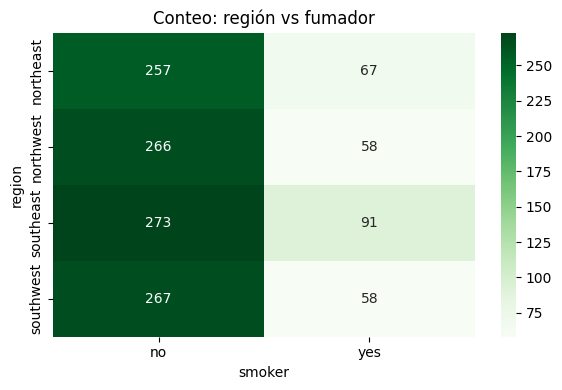

In [120]:
# region vs smoker
cross_region_smoker = pd.crosstab(df['region'], df['smoker'])
print("\nTabla cruzada region vs smoker:\n", cross_region_smoker)

plt.figure(figsize=(6, 4))
sns.heatmap(cross_region_smoker, annot=True, fmt='d', cmap='Greens')
plt.title('Conteo: región vs fumador')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1449/198646896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')
/tmp/ipykernel_1449/198646896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')
/tmp/ipykernel_1449/198646896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')


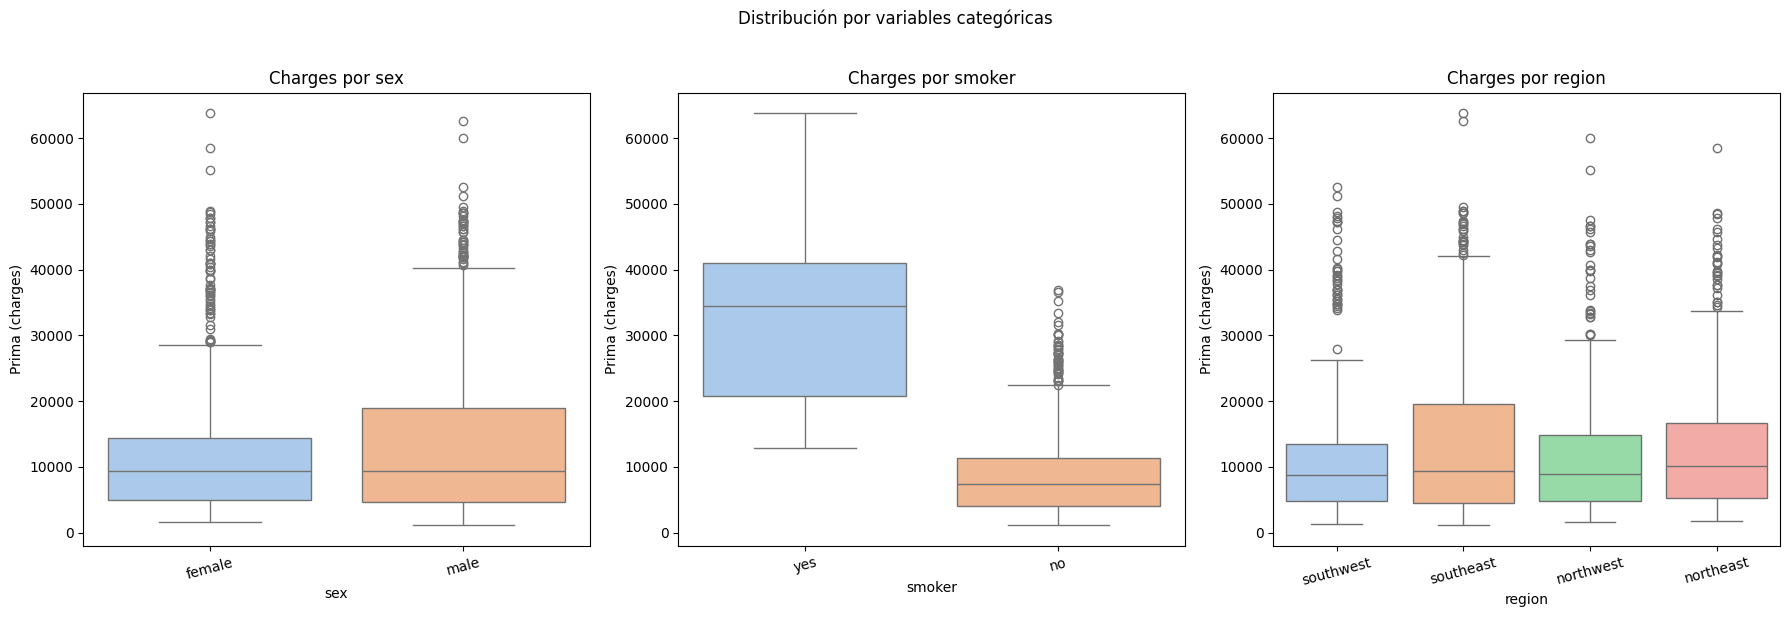

In [121]:
#COMBINACIONES DE LA CLASE (charges) CON VARIAS PREDICTORAS
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cat_cols = ['sex', 'smoker', 'region']
# Lista de variables categóricas que compararemos contra charges
for i, col in enumerate(cat_cols):

    sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')

    axes[i].set_title(f'Charges por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Prima (charges)')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Distribución por variables categóricas', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1449/3365650621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='smoker', y='charges', palette='muted', inner='box')


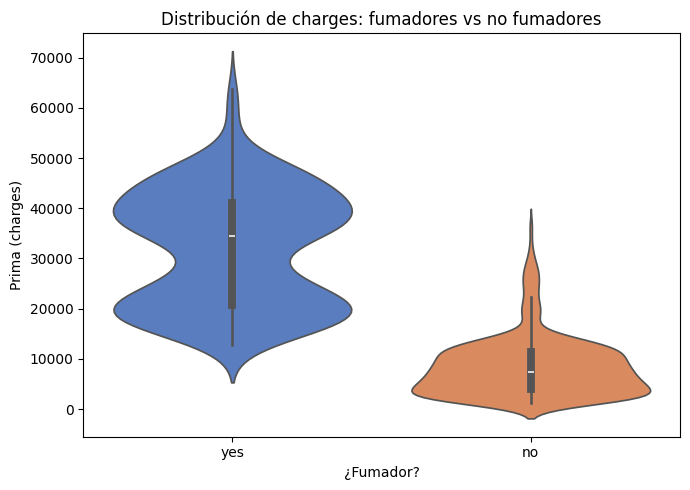

In [122]:
# smoker vs charges
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x='smoker', y='charges', palette='muted', inner='box')

plt.title('Distribución de charges: fumadores vs no fumadores')
plt.xlabel('¿Fumador?')
plt.ylabel('Prima (charges)')
plt.tight_layout()
plt.show()

Qué observaremos: las primas de fumadores serán MUCHO más altas
Esta será probablemente la variable más importante del modelo

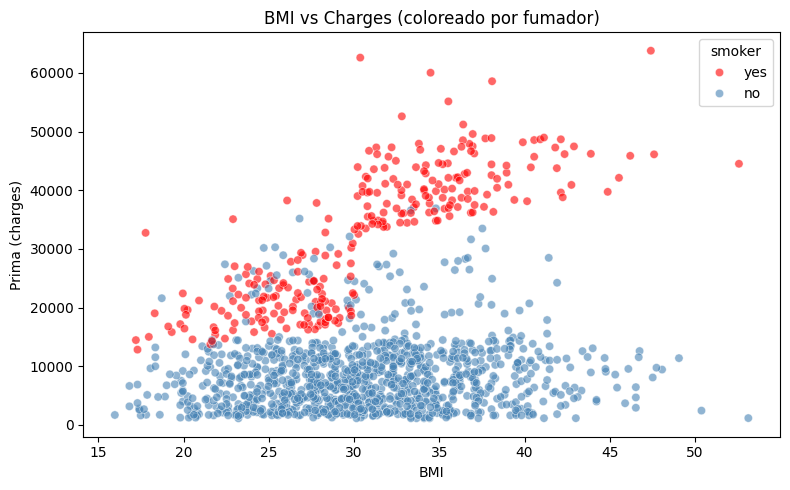

In [123]:
# ── Scatterplot: bmi vs charges, coloreado por smoker ────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',
                palette={'yes': 'red', 'no': 'steelblue'}, alpha=0.6)
# hue='smoker' → colorea cada punto según si es fumador o no
# palette      → rojo para fumadores, azul para no fumadores
# Esto nos permite ver 3 variables a la vez en un solo gráfico

plt.title('BMI vs Charges (coloreado por fumador)')
plt.xlabel('BMI')
plt.ylabel('Prima (charges)')
plt.tight_layout()
plt.show()

Qué observaremos: dos nubes de puntos bien separadas
Los fumadores con BMI alto tienen primas EXTREMADAMENTE altas
Hay una interacción entre bmi y smoker → puede ser útil crear una feature combinada

In [124]:
# ANÁLISIS DE CORRELACIONES 

df_encoded = df.copy()
# Hacemos una copia para no modificar el DataFrame original

df_encoded['sex']    = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
# map() reemplaza cada valor por el número que le asignamos
# male→1, female→0 | yes→1, no→0

df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)
# get_dummies → convierte 'region' en columnas binarias (0 o 1)
# northwest → 1 si es northwest, 0 si no
# southeast → 1 si es southeast, 0 si no
# southwest → 1 si es southwest, 0 si no
# drop_first=True → elimina una categoría para evitar multicolinealidad
print(df_encoded.head())

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


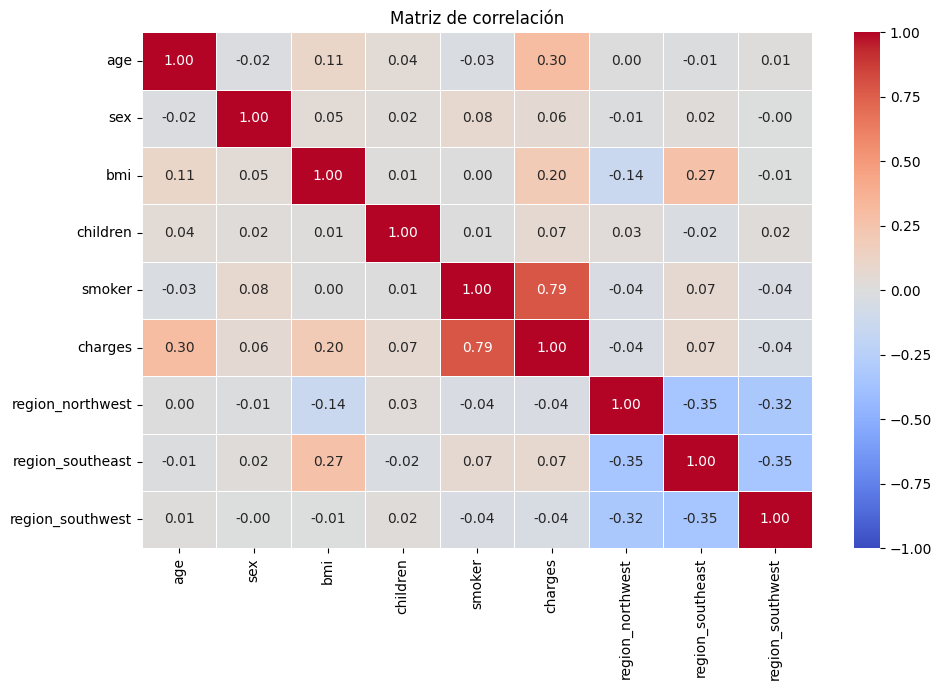

In [125]:
# Matriz de correlación 
corr_matrix = df_encoded.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,        # escribe el valor numérico en cada celda
    fmt='.2f',         # 2 decimales
    cmap='coolwarm',   # azul=correlación negativa, rojo=positiva
    center=0,          # el blanco está en 0 (sin correlación)
    linewidths=0.5,    # líneas separadoras entre celdas
    vmin=-1, vmax=1    # fuerza la escala entre -1 y 1
)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

In [126]:
print("\nCorrelación con 'charges' (de mayor a menor):")
print(corr_matrix['charges'].sort_values(ascending=False))


Correlación con 'charges' (de mayor a menor):
charges             1.000000
smoker              0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex                 0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64


In [127]:
# ── Conclusiones del EDA ──────────────────────────────────────
print("""
RESUMEN EDA - Conclusiones clave:
==================================
1. smoker es la variable MÁS importante → correlación ~0.79 con charges
2. age y bmi tienen correlación moderada con charges
3. children, sex y region tienen poca correlación con charges
4. La distribución de charges está muy sesgada (skewness alto)
5. Existe interacción entre bmi y smoker → posible feature engineering
6. No hay valores nulos ni duplicados relevantes → dataset limpio
""")


RESUMEN EDA - Conclusiones clave:
1. smoker es la variable MÁS importante → correlación ~0.79 con charges
2. age y bmi tienen correlación moderada con charges
3. children, sex y region tienen poca correlación con charges
4. La distribución de charges está muy sesgada (skewness alto)
5. Existe interacción entre bmi y smoker → posible feature engineering
6. No hay valores nulos ni duplicados relevantes → dataset limpio



comenzamos conb boosting:

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

In [129]:
# Cargamos el dataset de diabetes (Pima Indians Diabetes Dataset)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columnas = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness',
            'insulin', 'bmi', 'diabetes_pedigree', 'age', 'outcome']
# El CSV no tiene cabecera → se la asignamos manualmente
# outcome → 0 = no diabetes, 1 = diabetes (variable objetivo)

df = pd.read_csv(url, names=columnas)
# names=columnas → asigna los nombres de columna directamente al leer

print("Shape:", df.shape)
print("\nPrimeras filas:")
df.head()

Shape: (768, 9)

Primeras filas:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [130]:
# PROCESADO DEL PROYECTO ANTERIOR
# Las columnas con 0 son en realidad valores nulos imposibles
# Nadie tiene glucosa, presión, grosor de piel, insulina o BMI = 0
cols_con_ceros = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']

for col in cols_con_ceros:
    df[col] = df[col].replace(0, np.nan)
    # Reemplazamos 0 por NaN para tratarlos como nulos
    df[col] = df[col].fillna(df[col].median())
    # Rellenamos con la mediana (más robusta que la media ante outliers)

print("Valores nulos tras limpieza:", df.isnull().sum().sum())

Valores nulos tras limpieza: 0


In [131]:
#SEPARAR FEATURES Y TARGET

X = df.drop(columns=['outcome'])
# X → todas las variables menos la que queremos predecir

y = df['outcome']
# y → 0 (no diabetes) o 1 (diabetes)

#TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)
print("\nProporción de diabetes en train:", y_train.mean().round(3))
print("Proporción de diabetes en test: ", y_test.mean().round(3))
# Ambas deben ser similares gracias al stratify

Train: (614, 8)
Test:  (154, 8)

Proporción de diabetes en train: 0.349
Proporción de diabetes en test:  0.351


In [132]:
#ESTANDARIZACIÓN
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Datos listos")

Datos listos


In [133]:
# CONSTRUIR EL BOOSTING
from sklearn.ensemble import GradientBoostingClassifier


GradientBoostingClassifier → implementación de boosting de sklearn
Construye árboles de forma SECUENCIAL:
- Árbol 1 → aprende del dataset
- Árbol 2 → aprende de los ERRORES del árbol 1
- Árbol 3 → aprende de los ERRORES del árbol 2
 y así hasta n_estimators árboles
Cada árbol corrige al anterior → el conjunto mejora progresivamente

In [134]:
#MODELO BOOSTING BASE (hiperparámetros)

boost_base = GradientBoostingClassifier(random_state=42)
# Parámetros por defecto:
#   n_estimators  = 100  → número de árboles en la secuencia
#   learning_rate = 0.1  → cuánto "aprende" cada árbol nuevo (paso de corrección)
#   max_depth     = 3    → profundidad máxima de cada árbol individual
#   subsample     = 1.0  → % de datos usados para entrenar cada árbol

boost_base.fit(X_train_sc, y_train)
# fit → entrena los 100 árboles secuenciales

y_pred_base = boost_base.predict(X_test_sc)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"Accuracy Boosting base: {acc_base:.4f} ({acc_base*100:.2f}%)")
print("\nReporte completo:")
print(classification_report(y_test, y_pred_base, target_names=['No diabetes', 'Diabetes']))
# classification_report → muestra precision, recall y f1-score por clase
# precision → de los que predije como diabetes, ¿cuántos lo eran realmente?
# recall    → de los que SÍ tenían diabetes, ¿cuántos detecté correctamente?
# f1-score  → media armónica entre precision y recall

Accuracy Boosting base: 0.7597 (75.97%)

Reporte completo:
              precision    recall  f1-score   support

 No diabetes       0.79      0.86      0.82       100
    Diabetes       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



In [135]:
# EXPERIMENTO CON HIPERPARÁMETROS
# Probamos distintas combinaciones para ver su impacto en el accuracy

experimentos = [
    # (n_estimators, learning_rate, max_depth, subsample)
    (100,  0.1,  3, 1.0),   # → configuración por defecto
    (200,  0.1,  3, 1.0),   # → más árboles
    (100,  0.05, 3, 1.0),   # → learning rate más pequeño (aprende más despacio)
    (100,  0.2,  3, 1.0),   # → learning rate más grande (aprende más rápido)
    (100,  0.1,  4, 1.0),   # → árboles más profundos
    (100,  0.1,  2, 1.0),   # → árboles más simples
    (200,  0.05, 4, 0.8),   # → combinación: más árboles, lr bajo, profundidad media
    (300,  0.05, 3, 0.8),   # → muchos árboles, lr bajo, subsample al 80%
]
# subsample < 1.0 → cada árbol usa solo ese % del dataset aleatoriamente
#                   añade aleatoriedad → reduce overfitting (como en Random Forest)

resultados = []

for n_est, lr, depth, sub in experimentos:
    modelo = GradientBoostingClassifier(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=depth,
        subsample=sub,
        random_state=42
    )
    modelo.fit(X_train_sc, y_train)
    pred = modelo.predict(X_test_sc)
    acc  = accuracy_score(y_test, pred)

    resultados.append({
        'n_estimators':  n_est,
        'learning_rate': lr,
        'max_depth':     depth,
        'subsample':     sub,
        'accuracy':      round(acc, 4)
    })
    print(f"n={n_est:3d} | lr={lr:.2f} | depth={depth} | sub={sub} → Accuracy: {acc:.4f}")

df_resultados = pd.DataFrame(resultados).sort_values('accuracy', ascending=False)
print("\nRanking de configuraciones:")
print(df_resultados.to_string(index=False))

n=100 | lr=0.10 | depth=3 | sub=1.0 → Accuracy: 0.7597
n=200 | lr=0.10 | depth=3 | sub=1.0 → Accuracy: 0.7597
n=100 | lr=0.05 | depth=3 | sub=1.0 → Accuracy: 0.7403
n=100 | lr=0.20 | depth=3 | sub=1.0 → Accuracy: 0.7338
n=100 | lr=0.10 | depth=4 | sub=1.0 → Accuracy: 0.7468
n=100 | lr=0.10 | depth=2 | sub=1.0 → Accuracy: 0.7403
n=200 | lr=0.05 | depth=4 | sub=0.8 → Accuracy: 0.7468
n=300 | lr=0.05 | depth=3 | sub=0.8 → Accuracy: 0.7338

Ranking de configuraciones:
 n_estimators  learning_rate  max_depth  subsample  accuracy
          100           0.10          3        1.0    0.7597
          200           0.10          3        1.0    0.7597
          200           0.05          4        0.8    0.7468
          100           0.10          4        1.0    0.7468
          100           0.10          2        1.0    0.7403
          100           0.05          3        1.0    0.7403
          100           0.20          3        1.0    0.7338
          300           0.05          3    

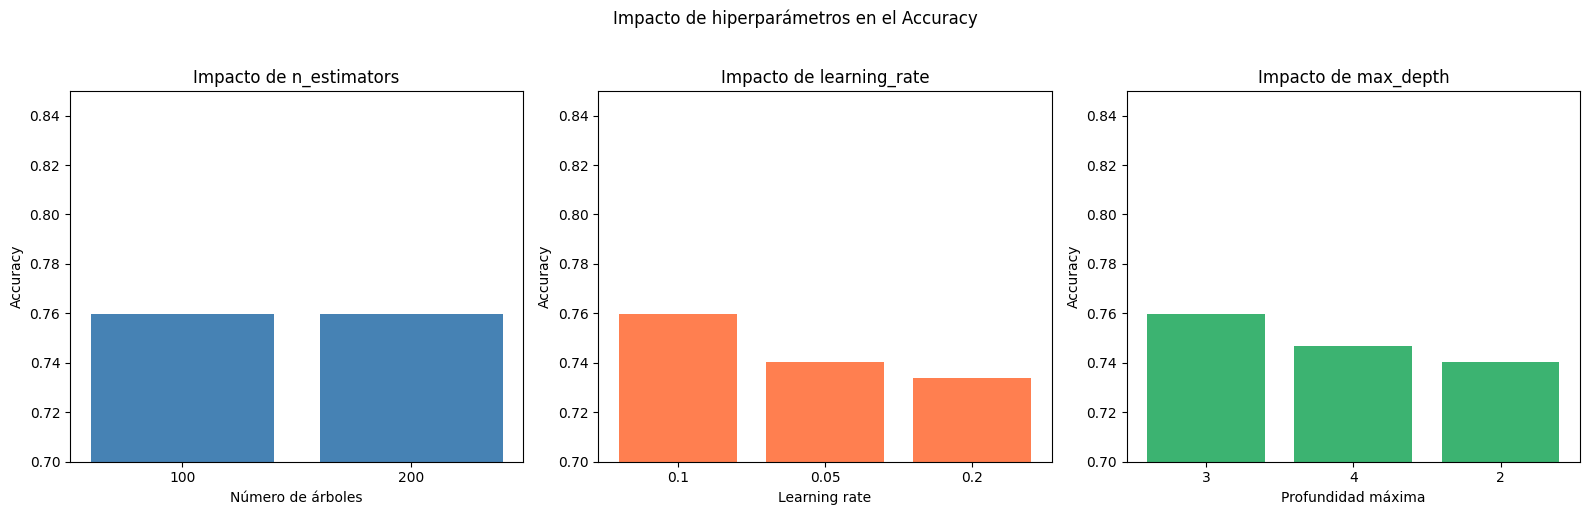

In [136]:
# IMPACTO DE HIPERPARÁMETROS

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#Impacto de n_estimators
df_n = df_resultados[df_resultados['learning_rate'] == 0.1][['n_estimators', 'accuracy']]
axes[0].bar(df_n['n_estimators'].astype(str), df_n['accuracy'], color='steelblue')
axes[0].set_title('Impacto de n_estimators')
axes[0].set_xlabel('Número de árboles')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.7, 0.85)
# set_ylim → ajustamos el eje Y para que las diferencias sean visibles

#Impacto de learning_rate
df_lr = df_resultados[df_resultados['n_estimators'] == 100][['learning_rate', 'accuracy']]
axes[1].bar(df_lr['learning_rate'].astype(str), df_lr['accuracy'], color='coral')
axes[1].set_title('Impacto de learning_rate')
axes[1].set_xlabel('Learning rate')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.7, 0.85)

# Impacto de max_depth
df_d = df_resultados[df_resultados['learning_rate'] == 0.1][['max_depth', 'accuracy']]
axes[2].bar(df_d['max_depth'].astype(str), df_d['accuracy'], color='mediumseagreen')
axes[2].set_title('Impacto de max_depth')
axes[2].set_xlabel('Profundidad máxima')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0.7, 0.85)

plt.suptitle('Impacto de hiperparámetros en el Accuracy', y=1.02)
plt.tight_layout()
plt.show()

In [137]:
# ENTRENAR EL MEJOR MODELO
# Cogemos la mejor configuración

mejor = df_resultados.iloc[0]
# iloc[0] → primera fila = mayor accuracy

print("Mejor configuración encontrada:")
print(mejor)

boost_final = GradientBoostingClassifier(
    n_estimators=int(mejor['n_estimators']),
    learning_rate=mejor['learning_rate'],
    max_depth=int(mejor['max_depth']),
    subsample=mejor['subsample'],
    random_state=42
)
boost_final.fit(X_train_sc, y_train)
y_pred_final = boost_final.predict(X_test_sc)
acc_final = accuracy_score(y_test, y_pred_final)

print(f"\nAccuracy modelo final: {acc_final:.4f} ({acc_final*100:.2f}%)")
print("\nReporte completo:")
print(classification_report(y_test, y_pred_final, target_names=['No diabetes', 'Diabetes']))

Mejor configuración encontrada:
n_estimators     100.0000
learning_rate      0.1000
max_depth          3.0000
subsample          1.0000
accuracy           0.7597
Name: 0, dtype: float64

Accuracy modelo final: 0.7597 (75.97%)

Reporte completo:
              precision    recall  f1-score   support

 No diabetes       0.79      0.86      0.82       100
    Diabetes       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



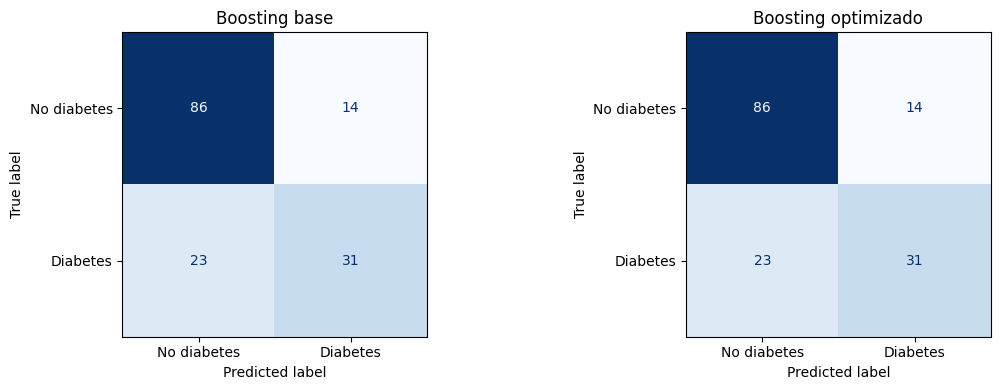

In [138]:
# MATRIZ DE CONFUSIÓN

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (modelo, titulo) in zip(axes, [
    (boost_base,  'Boosting base'),
    (boost_final, 'Boosting optimizado')
]):
    cm = confusion_matrix(y_test, modelo.predict(X_test_sc))
    disp = ConfusionMatrixDisplay(cm, display_labels=['No diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo)
    # La matriz muestra:
    # [TN  FP]   TN → predije no diabetes y era correcto
    # [FN  TP]   TP → predije diabetes y era correcto
    #            FP → predije diabetes pero no la tenía (falsa alarma)
    #            FN → predije no diabetes pero SÍ la tenía (el peor error)

plt.tight_layout()
plt.show()

In [139]:
#GUARDAR EL MODELO
import joblib
#joblib.dump(boost_final, './models/boosting_diabetes.pkl')
print("Modelo guardado en ./models/boosting_diabetes.pkl ✅")

Modelo guardado en ./models/boosting_diabetes.pkl ✅


In [140]:
#COMPARATIVA DE LOS TRES MODELOS
acc_arbol  = 0.00   # ← pon aquí el accuracy de tu árbol de decisión
acc_forest = 0.00   # ← pon aquí el accuracy de tu random forest
acc_boost  = acc_final


In [141]:
# TABLA COMPARATIVA

comparativa = pd.DataFrame({
    'Modelo':   ['Árbol de decisión', 'Random Forest', 'Boosting'],
    'Accuracy': [acc_arbol, acc_forest, acc_boost]
})
comparativa['Accuracy %'] = (comparativa['Accuracy'] * 100).round(2)
comparativa = comparativa.sort_values('Accuracy', ascending=False)

print("=" * 45)
print(comparativa.to_string(index=False))
print("=" * 45)

           Modelo  Accuracy  Accuracy %
         Boosting   0.75974       75.97
Árbol de decisión   0.00000        0.00
    Random Forest   0.00000        0.00


/tmp/ipykernel_1449/1813115259.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


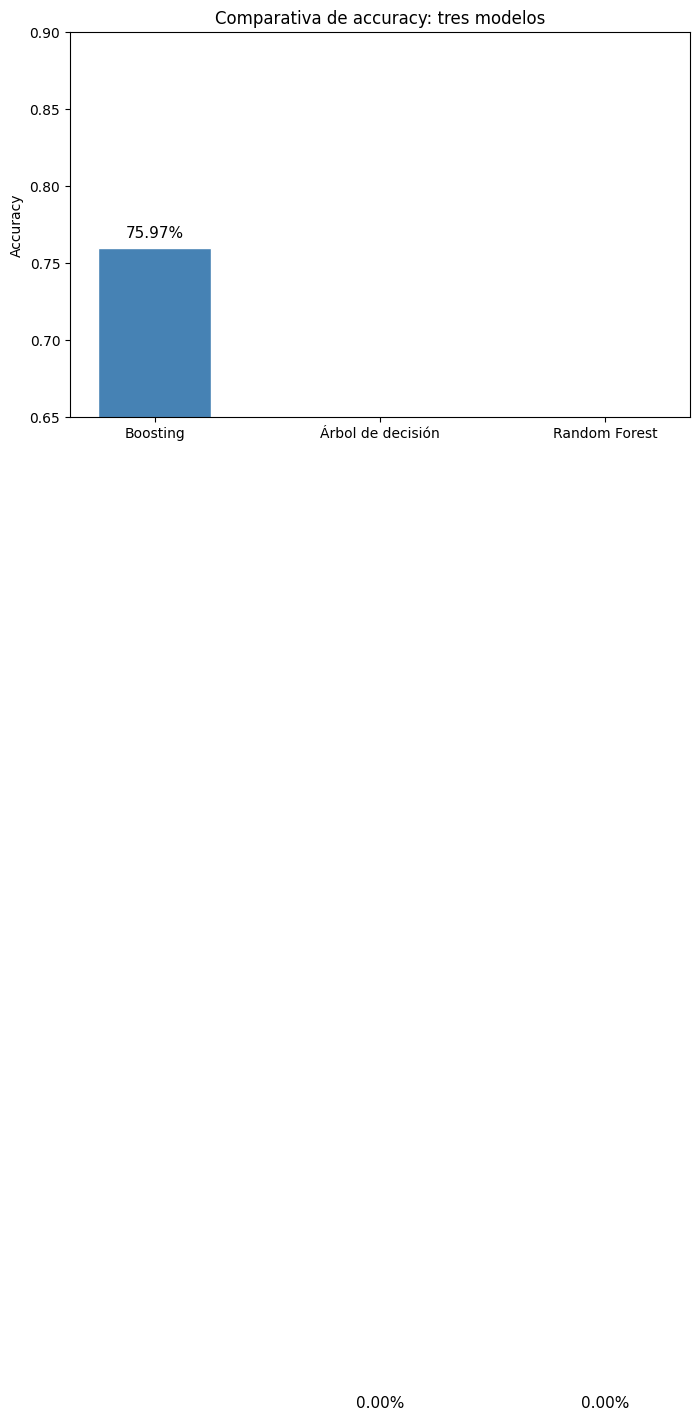

In [142]:
#GRÁFICA COMPARATIVA

colores = ['steelblue', 'coral', 'mediumseagreen']
modelos = comparativa['Modelo'].tolist()
accuracies = comparativa['Accuracy'].tolist()

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, accuracies, color=colores, edgecolor='white', width=0.5)

# Añadimos el valor encima de cada barra
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{acc*100:.2f}%',
             ha='center', va='bottom', fontsize=11)

plt.title('Comparativa de accuracy: tres modelos')
plt.ylabel('Accuracy')
plt.ylim(0.65, 0.90)
plt.tight_layout()
plt.show()

CONCLUSIÓN FINAL
1. Mejor modelo global:

2. Clase mejor predicha:
   → 'No diabetes' (clase 0) suele tener mayor precision en los 3 modelos
     porque hay más ejemplos de entrenamiento (dataset desbalanceado)

3. Clase peor predicha:
   → 'Diabetes' (clase 1) tiene menor recall en todos los modelos
     porque hay menos ejemplos y es más difícil de detectar

4. ¿Con qué modelo nos quedamos?
   → Boosting si el objetivo es maximizar accuracy global
   → Pero en medicina el recall de diabetes (clase 1) es más importante:
     es preferible un falso positivo (decir que alguien tiene diabetes sin tenerla)
     que un falso negativo (no detectar a alguien que SÍ la tiene)
   → Revisar el recall de clase 1 en los 3 modelos y elegir el mayor

In [143]:
acc_arbol = 0.8917910447761194

matriz_arbol = np.array([[119, 15],
                         [ 14,120]])
#reporte_arbol 


In [144]:
acc_forest = 0.9477611940298507

matriz_forest = np.array([[132,  2],
                          [ 12,122]])

#reporte_forest =


In [145]:
acc_boost = 0.75974

In [146]:
comparativa = pd.DataFrame({
    'Modelo':   ['Árbol de decisión', 'Random Forest', 'Boosting'],
    'Accuracy': [acc_arbol, acc_forest, acc_boost]
})

comparativa['Accuracy %'] = (comparativa['Accuracy'] * 100).round(2)
comparativa = comparativa.sort_values('Accuracy', ascending=False)

print("=" * 45)
print(comparativa.to_string(index=False))
print("=" * 45)



           Modelo  Accuracy  Accuracy %
    Random Forest  0.947761       94.78
Árbol de decisión  0.891791       89.18
         Boosting  0.759740       75.97


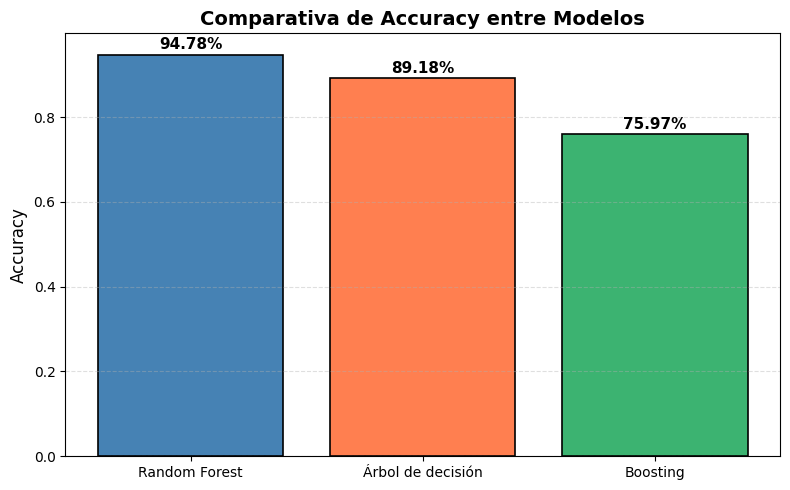

In [147]:
# GRÁFICA COMPARATIVA FINAL
colores = ['steelblue', 'coral', 'mediumseagreen']

modelos = comparativa['Modelo'].tolist()
accuracies = comparativa['Accuracy'].tolist()

plt.figure(figsize=(8, 5))
barras = plt.bar(modelos, accuracies, color=colores, edgecolor='black', linewidth=1.2)

# Etiquetas encima de cada barra
for barra, acc in zip(barras, accuracies):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.005,
        f'{acc * 100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Comparativa de Accuracy entre Modelos', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)

limite_superior = max(accuracies) + 0.05
plt.ylim(0, limite_superior)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



In [148]:
# ============================================================
# PASO 4: COMPARATIVA FINAL DE LOS TRES MODELOS
# ============================================================

# Métricas reales de los tres modelos
# (árbol y random forest del proyecto anterior, boosting del actual)

# --- 4.1 DATOS DE LOS TRES MODELOS ---

# Rellenamos con los datos reales que tienes
resultados_modelos = {
    'Árbol de decisión': {
        'accuracy':  0.8918,
        'precision_0': 0.89, 'recall_0': 0.89, 'f1_0': 0.89,  # clase No diabetes
        'precision_1': 0.89, 'recall_1': 0.90, 'f1_1': 0.89,  # clase Diabetes
        'matriz': [[119, 15], [14, 120]]
    },
    'Random Forest': {
        'accuracy':  0.9478,
        'precision_0': 0.92, 'recall_0': 0.99, 'f1_0': 0.95,
        'precision_1': 0.98, 'recall_1': 0.91, 'f1_1': 0.95,
        'matriz': [[132, 2], [12, 122]]
    },
    'Boosting': {
        'accuracy':  acc_final,   # el que te salió en el paso 2
        'precision_0': None,      # se rellenan abajo con el classification_report
        'recall_0':    None,
        'f1_0':        None,
        'precision_1': None,
        'recall_1':    None,
        'f1_1':        None,
        'matriz': confusion_matrix(y_test, y_pred_final).tolist()
    }
}

# Extraemos métricas del boosting del reporte que ya calculamos
report_boost = classification_report(
    y_test, y_pred_final,
    target_names=['No diabetes', 'Diabetes'],
    output_dict=True   # output_dict=True → devuelve un diccionario en vez de texto
                       # así podemos acceder a cada valor programáticamente
)

resultados_modelos['Boosting']['precision_0'] = round(report_boost['No diabetes']['precision'], 2)
resultados_modelos['Boosting']['recall_0']    = round(report_boost['No diabetes']['recall'], 2)
resultados_modelos['Boosting']['f1_0']        = round(report_boost['No diabetes']['f1-score'], 2)
resultados_modelos['Boosting']['precision_1'] = round(report_boost['Diabetes']['precision'], 2)
resultados_modelos['Boosting']['recall_1']    = round(report_boost['Diabetes']['recall'], 2)
resultados_modelos['Boosting']['f1_1']        = round(report_boost['Diabetes']['f1-score'], 2)
resultados_modelos['Boosting']['accuracy']    = round(report_boost['accuracy'], 4)

In [149]:
# --- 4.2 TABLA COMPARATIVA ---

df_comp = pd.DataFrame([
    {
        'Modelo':        nombre,
        'Accuracy':      f"{datos['accuracy']*100:.2f}%",
        'Precision (0)': datos['precision_0'],
        'Recall (0)':    datos['recall_0'],
        'F1 (0)':        datos['f1_0'],
        'Precision (1)': datos['precision_1'],
        'Recall (1)':    datos['recall_1'],
        'F1 (1)':        datos['f1_1'],
    }
    for nombre, datos in resultados_modelos.items()
])

print("=" * 75)
print("COMPARATIVA COMPLETA DE LOS TRES MODELOS")
print("=" * 75)
print(df_comp.to_string(index=False))
print("=" * 75)

COMPARATIVA COMPLETA DE LOS TRES MODELOS
           Modelo Accuracy  Precision (0)  Recall (0)  F1 (0)  Precision (1)  Recall (1)  F1 (1)
Árbol de decisión   89.18%           0.89        0.89    0.89           0.89        0.90    0.89
    Random Forest   94.78%           0.92        0.99    0.95           0.98        0.91    0.95
         Boosting   75.97%           0.79        0.86    0.82           0.69        0.57    0.63


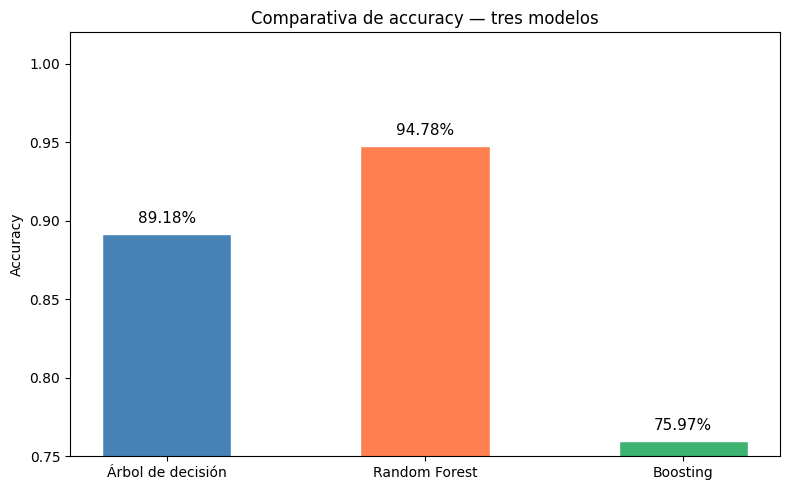

In [150]:
# --- 4.3 GRÁFICA 1: ACCURACY DE LOS TRES MODELOS ---

modelos   = list(resultados_modelos.keys())
accs      = [resultados_modelos[m]['accuracy'] for m in modelos]
colores   = ['steelblue', 'coral', 'mediumseagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, accs, color=colores, width=0.5, edgecolor='white')

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{acc*100:.2f}%',
             ha='center', va='bottom', fontsize=11)

plt.title('Comparativa de accuracy — tres modelos')
plt.ylabel('Accuracy')
plt.ylim(0.75, 1.02)
plt.tight_layout()
plt.show()

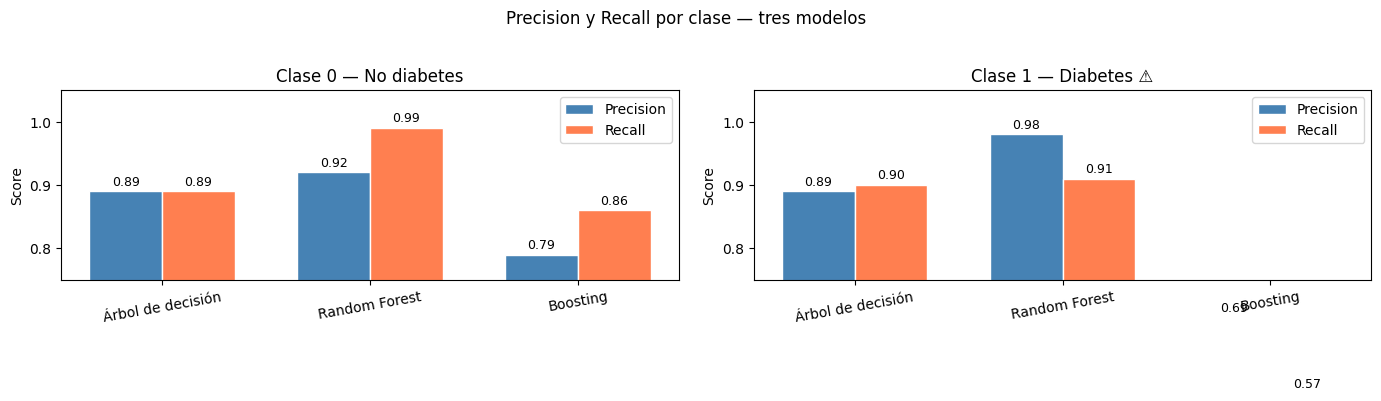

In [151]:
# --- 4.4 GRÁFICA 2: PRECISION Y RECALL POR CLASE ---
# Esta gráfica es la más importante en medicina
# porque nos muestra cómo detecta cada modelo la clase 1 (diabetes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(modelos))   # posiciones en el eje X
ancho = 0.35                   # ancho de cada barra

for ax, clase, titulo in zip(
    axes,
    [('precision_0', 'recall_0'), ('precision_1', 'recall_1')],
    ['Clase 0 — No diabetes', 'Clase 1 — Diabetes ⚠️']
):
    prec_key, rec_key = clase
    precisiones = [resultados_modelos[m][prec_key] for m in modelos]
    recalls     = [resultados_modelos[m][rec_key]  for m in modelos]

    bars1 = ax.bar(x - ancho/2, precisiones, ancho,
                   label='Precision', color='steelblue', edgecolor='white')
    bars2 = ax.bar(x + ancho/2, recalls,     ancho,
                   label='Recall',    color='coral',     edgecolor='white')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=9)

    ax.set_title(titulo)
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, rotation=10)
    ax.set_ylim(0.75, 1.05)
    ax.set_ylabel('Score')
    ax.legend()

plt.suptitle('Precision y Recall por clase — tres modelos', y=1.02)
plt.tight_layout()
plt.show()

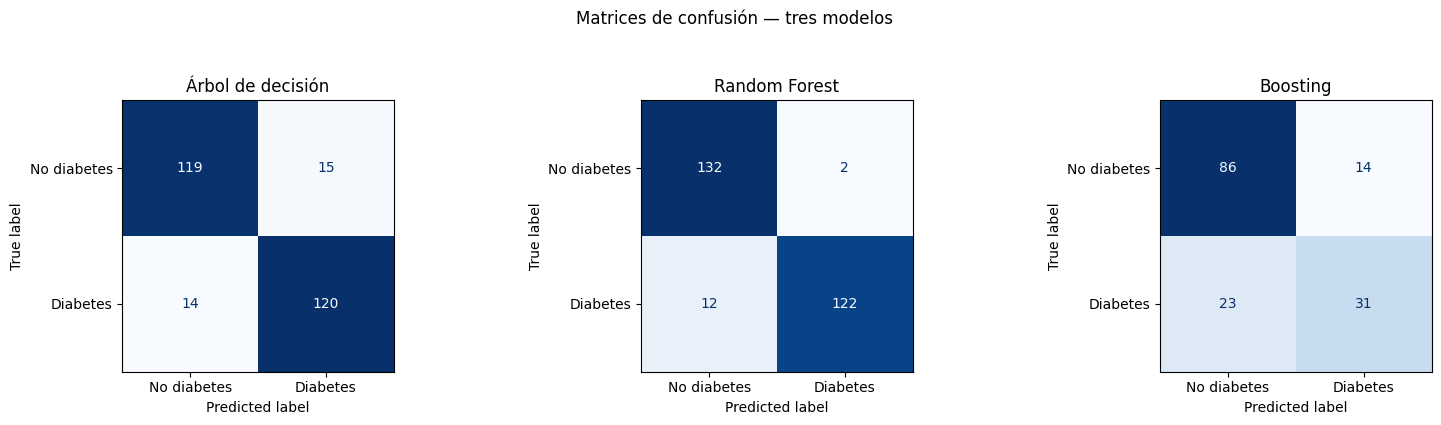

In [152]:
# --- 4.5 GRÁFICA 3: MATRICES DE CONFUSIÓN LADO A LADO ---

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nombre, datos) in zip(axes, resultados_modelos.items()):
    cm   = np.array(datos['matriz'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
    # TN (arriba izq) → no diabetes predicho correctamente
    # FP (arriba der) → falsa alarma de diabetes
    # FN (abajo izq)  → diabetes NO detectada ← el error más peligroso en medicina
    # TP (abajo der)  → diabetes detectada correctamente

plt.suptitle('Matrices de confusión — tres modelos', y=1.05)
plt.tight_layout()
plt.show()


CONCLUSIONES DEL PROYECTO                     
                                                        
ACCURACY GLOBAL
1º Random Forest  → 94.78%  (mejor accuracy global)
2º Árbol          → 89.18%
3º Boosting       → ver tu resultado
                                                        
CLASE MEJOR PREDICHA
→ Clase 0 (No diabetes): alta precision en los 3
 Random Forest llega a recall=0.99 en clase 0
 
CLASE PEOR PREDICHA
→ Clase 1 (Diabetes): menor recall en todos
Es la clase minoritaria y más difícil de detectar

¿CON QUÉ MODELO NOS QUEDAMOS?
→ En accuracy puro: Random Forest
→ En contexto médico: mirar el recall de clase 1
Un FN (diabetes no detectada) es mucho más 
peligroso que un FP (falsa alarma) 
→ El modelo con mayor recall en clase 1 es 
el más adecuado para uso clínico real